## Construcción del set de datos para el problema.



In [1]:
import numpy as np
data = np.random.randint(1, 1001, 10000) # Arreglo de 10,000 enteros aleatorios entre 1 y 1000
total_sum = np.sum(data) # Calcular la suma total
target_sum = total_sum / 2 # Calcular el valor objetivo para cada subconjunto (la mitad de la suma total)
print(f"Suma total del arreglo: {total_sum}")
print(f"Suma esperada del subconjunto: {target_sum}")

Suma total del arreglo: 4980387
Suma esperada del subconjunto: 2490193.5


## Implementación con PyGAD


In [2]:
import pygad

def fitness_func(ga_instance, solution, solution_idx):
    suma = np.dot(data, solution)
    # Se va a definir la diferencia como lo que se quiere reducir. El negativo lo convierte en un problema de maximización
    fitness = - np.abs(suma - target_sum)
    return fitness


## Implementación del algoritmo

Se construye el algoritmo de acuerdo con los parámetros de PyGad


In [3]:
num_genes = len(data) #Tamaño del cromosoma
def progreso(ga_instance):
    print("Generación:", ga_instance.generations_completed,", Mejor fitness:", ga_instance.best_solution()[1])

ga_instance = pygad.GA(
    num_generations=100, #Número total de iteraciones. Cuántas veces se realizará el ciclo
    sol_per_pop=200, #Tamaño de la población de individuos.
    num_parents_mating=80, #Número de padres elegidos para reproducirse.
    keep_parents=30, #Si los padres se conservan en el proceso de selección. No toda la población es nueva
    fitness_func=fitness_func, #La función de fitness definida
    num_genes=num_genes, #Tamaño de los genes que se generarán
    gene_type=int,
    gene_space=[0,1],
    #init_range_low=0,
    #init_range_high=2,

    parent_selection_type="tournament", # Steady-State Selection. Se seleccionan los padres con mejor fitness
    K_tournament=3,
                                 # rws — Roulette Wheel Selection. A mayor fitness hay mayor probabilidad de elección
                                 # sus — Stochastic Universal Sampling. Basado en la transformada inversa, para generar no solo los más probables.
                                 # rank — Rank Selection. La probabilidad depende de la organización por fitness, no del valor del fitness
                                 # random — Selección aleatoria. No tiene en cuenta el fitness
                                 # tournament — Tournament Selection. Se hacen grupos de k y de cada grupo gana el mejor
    crossover_type="single_point", # single_point (Single-Point Crossover). Se toma un punto de corte entre A[0ind], B[ind:]
                                   # two_points. Se toman dos puntos y se intercambia la parte de la mitad.
                                   # uniform. Se hace una máscara aleatoria para seleccionar de uno u otro cromosoma
                                   # scattered. Es lo mismo que uniform, pero se construye una máscara binaria
    mutation_type="random", # random. Se eligen aleatoriamente ciertos genes y estos se cambian según el rango permitido
                            # swap. Intercambia dos genes dentro del cromosoma
                            # scramble. Toma un subgrupo de genes y los desordena, equivalentemente a un permutación
                            # inversion. Toma un conjunto de genes y les invierte el orden.
    mutation_percent_genes=10, #Qué porcentaj de los genes se puede cambiar.
    keep_elitism=4, #Qué número de los mejores cromosomas se conservan.
    on_generation=progreso # Callback to print progress
)

print("PyGAD GA configurado, corriendo el algoritmo")
ga_instance.run()

best_solution, best_fitness, solution_idx = ga_instance.best_solution()

subset1 = data[best_solution == 1]
subset2 = data[best_solution == 0]

subset1_sum = np.sum(subset1)
subset2_sum = np.sum(subset2)

print(f"Best solution found after {ga_instance.num_generations} generations:")
print(f"  Chromosome (partial display): {best_solution[:10]}...{best_solution[-10:]}")
print(f"  Fitness value: {best_fitness}")
print(f"  Sum of subset 1: {subset1_sum}")
print(f"  Sum of subset 2: {subset2_sum}")
print(f"  Difference between subsets sums: {np.abs(subset1_sum - subset2_sum)}")
print(f"  Target sum: {target_sum}")
print(f"  Difference from target sum: {np.abs(subset1_sum - target_sum)}")


c:\Users\000010478\Downloads\Curso_TAIA\.venv\Lib\site-packages\pygad\utils\validation.py:1287: UserWarning: Both keep_parents (=30) and keep_elitism (=4) are set. Because keep_elitism is greater than 0, it takes precedence and keep_parents is ignored. To make keep_parents take effect, set keep_elitism=0.
  warnings.warn(f"Both keep_parents (={self.keep_parents}) and keep_elitism (={self.keep_elitism}) are set. Because keep_elitism is greater than 0, it takes precedence and keep_parents is ignored. To make keep_parents take effect, set keep_elitism=0.")


PyGAD GA configurado, corriendo el algoritmo
Generación: 1 , Mejor fitness: -231.5
Generación: 2 , Mejor fitness: -62.5
Generación: 3 , Mejor fitness: -62.5
Generación: 4 , Mejor fitness: -62.5
Generación: 5 , Mejor fitness: -9.5
Generación: 6 , Mejor fitness: -9.5
Generación: 7 , Mejor fitness: -9.5
Generación: 8 , Mejor fitness: -7.5
Generación: 9 , Mejor fitness: -7.5
Generación: 10 , Mejor fitness: -7.5
Generación: 11 , Mejor fitness: -7.5
Generación: 12 , Mejor fitness: -7.5
Generación: 13 , Mejor fitness: -7.5
Generación: 14 , Mejor fitness: -7.5
Generación: 15 , Mejor fitness: -7.5
Generación: 16 , Mejor fitness: -7.5
Generación: 17 , Mejor fitness: -7.5
Generación: 18 , Mejor fitness: -2.5
Generación: 19 , Mejor fitness: -2.5
Generación: 20 , Mejor fitness: -2.5
Generación: 21 , Mejor fitness: -2.5
Generación: 22 , Mejor fitness: -2.5
Generación: 23 , Mejor fitness: -2.5
Generación: 24 , Mejor fitness: -2.5
Generación: 25 , Mejor fitness: -2.5
Generación: 26 , Mejor fitness: -2

In [4]:
best_solution, best_fitness, solution_idx = ga_instance.best_solution()

subset1 = data[best_solution == 1]
subset2 = data[best_solution == 0]

subset1_sum = np.sum(subset1)
subset2_sum = np.sum(subset2)

print(f"Best solution found after {ga_instance.num_generations} generations:")
print(f"  Chromosome (partial display): {best_solution[:10]}...{best_solution[-10:]}")
print(f"  Fitness value: {best_fitness}")
print(f"  Sum of subset 1: {subset1_sum}")
print(f"  Sum of subset 2: {subset2_sum}")
print(f"  Difference between subsets sums: {np.abs(subset1_sum - subset2_sum)}")
print(f"  Target sum: {target_sum}")
print(f"  Difference from target sum: {np.abs(subset1_sum - target_sum)}")

Best solution found after 100 generations:
  Chromosome (partial display): [1 1 0 1 0 0 0 1 0 0]...[0 0 1 1 0 0 1 0 0 1]
  Fitness value: -1.5
  Sum of subset 1: 2490192
  Sum of subset 2: 2490195
  Difference between subsets sums: 3
  Target sum: 2490193.5
  Difference from target sum: 1.5


## Implementación con DEAP



In [5]:
from deap import base, creator, tools, algorithms
import random

if hasattr(creator, "FitnessMax"):
    del creator.FitnessMax
if hasattr(creator, "Individual"):
    del creator.Individual

creator.create("FitnessMax", base.Fitness, weights=(-1.0,)) #Hereda la clase fitness, weights significa que es maximización
creator.create("Individual", list, fitness=creator.FitnessMax) #El individuo se representa por una lista, pero tiene adicionalmente una función de fitness asociada
toolbox = base.Toolbox() #Esta es la herramienta fundamental sobre la que se crearán los operadores evolutivos
toolbox.register("attr_item", random.randint, 0, 1) #Registra el atributo: attr_item para generar enteros aleatorios entre 0 y 1 para cada gene.
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_item, n=len(data)) # Registra la función para crear un individuo de tamaño len(data)
toolbox.register("population", tools.initRepeat, list, toolbox.individual) #Registra la función de población para crear una lista de individuos

def evaluate(individual): #Función de fitness
    subset1_sum = np.dot(data, np.array(individual))
    return np.abs(subset1_sum - target_sum),
toolbox.register("evaluate", evaluate) #Registra la función de fitness para ser evaluada por los individuos

# Registro de los operadores genéticos del algoritmo
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.1)
toolbox.register("select", tools.selTournament, tournsize=3)


In [6]:
import time

POPULATION_SIZE = 200
GENERATIONS = 100
CXPB = 0.7  # Crossover probability
MUTPB = 0.2  # Mutation probability

population = toolbox.population(n=POPULATION_SIZE) #Creación de la población inicial

stats = tools.Statistics(lambda ind: ind.fitness.values) #Crear una estadística para verificar el comportamiento del entrenamiento
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

print("Comenzando la solución")
halloffame = tools.HallOfFame(1) # halloffame se usa para almacenar la mejor solución jamás obtenida

population, logbook = algorithms.eaSimple(population, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=GENERATIONS,
                                        stats=stats, halloffame=halloffame, verbose=True)
best_individual = halloffame[0]
# 17. Print the best individual (chromosome) and its fitness
print(f"\nMejor solución encontrada luego de {GENERATIONS} generaciones:")
print(f"Función de fitness: {best_individual.fitness.values[0]}")

#Soluciones:
subset1 = data[np.array(best_individual) == 1]
subset2 = data[np.array(best_individual) == 0]
subset1_sum = np.sum(subset1)
subset2_sum = np.sum(subset2)

print(f"Suma de los subconjuntos 1: {subset1_sum}, 2: {subset2_sum}")



Comenzando la solución
gen	nevals	avg    	std    	min  	max    
0  	200   	23941.4	17113.5	136.5	85062.5
1  	153   	14046.2	12021.4	136.5	58772.5
2  	149   	10438.2	10199.2	230.5	49908.5
3  	155   	11678.6	10824.2	192.5	55988.5
4  	159   	12515.8	12273.5	192.5	69916.5
5  	145   	9611.05	9174.3 	23.5 	49708.5
6  	147   	11100.7	10503.7	144.5	51415.5
7  	159   	12313.6	12759.7	81.5 	75638.5
8  	136   	10050.4	10259.6	81.5 	49263.5
9  	156   	9142.79	9021.52	28.5 	50269.5
10 	159   	8984.18	8741.51	57.5 	47440.5
11 	155   	10774.5	10049.8	57.5 	46903.5
12 	147   	9726.23	9348.01	57.5 	41519.5
13 	158   	9320.57	8266.3 	57.5 	38827.5
14 	148   	10243.2	10135.2	57.5 	69547.5
15 	155   	9687.17	9920.65	44.5 	44976.5
16 	154   	8187.9 	8864.27	57.5 	56919.5
17 	166   	10800.5	11416.8	57.5 	59084.5
18 	142   	8494.74	9122.61	57.5 	46926.5
19 	166   	9592.66	9098.8 	10.5 	49561.5
20 	154   	7526.91	7441.38	10.5 	47672.5
21 	156   	8676.51	9380.4 	10.5 	64206.5
22 	145   	7768.93	9061.74	10.5 	6

## Implementación Manual


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

class solucion:
  def __init__(self, V=[], S=0, cromosoma=[]):
    n=len(data)
    self.V=V
    self.S=S
    if(len(cromosoma)==0):
      self.X=np.random.randint(size=n, low=0, high=2)
    else:
      self.X=cromosoma.copy()
    self.Z=self.f() #Z es la variable que representa el valor de fitnness de la solución

  def f(self, mostrar=False): #Función de Fitness
    salida=np.abs(np.dot(self.X, self.V)-self.S)
    return salida



Mejor valor de Z: 246.5
Mejor Z original:  246.5
Mejor Z Luego de prunning:  246.5
Mejor Z luego de mutación:  246.5
Mejor Z luego de reproducción:  32.5


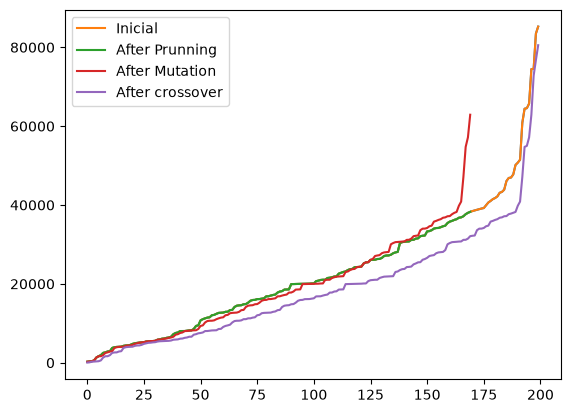

In [8]:
m=200 #Tamaño de la población
Np=30 #Dimensión del prunning
Nm=30 #Dimensión de la mutación
Nc=30 #Dimensión de la reproducción

P=[solucion(data,target_sum) for i in range(m)]

Z=[xi.Z for xi in P] #Valor de fitness de todas las soluciones
plt.plot(sorted(Z))
plt.grid()
print('Mejor valor de Z:',min(Z))

def prunning(P, Np): #Poda
  Z=np.array([xi.Z for xi in P])
  ind=np.argsort(-Z)[:Np]
  P=[P[i] for i in range(len(P)) if i not in ind]
  return P

def mutacion(P, Nm, num): #num representa cuantos genes modificamos
  #Vamos a elegir para mutar, a las soluciones más malas. Conservando las mejores con menor probabilidad de mutación
  d=np.array([xi.Z for xi in P])
  Pr=d/np.sum(d)
  ind=np.random.choice(size=Nm, a=range(len(Pr)), p=Pr) #ind representa los seres de la población a modificar
  for i in ind:
    for j in np.random.choice(size=num, a=range(len(data))):
      P[i].X[j]=1-P[i].X[j]
    P[i].Z=P[i].f()
  return P

def reproduccion(P, Nc):
  ind=np.random.randint(size=(Nc,2), low=0, high=len(P))
  L=int(len(P[0].X)/2)
  for i,j in ind:
    Xi=P[i].X.copy()
    Xj=P[j].X.copy()
    #print(np.concatenate([Xi[:L],Xj[L:]]))
    P.append(solucion(data,target_sum,np.concatenate([Xi[:L],Xj[L:]])))
  return P

Z=[xi.Z for xi in P]
print('Mejor Z original: ', min(Z))
plt.plot(sorted(Z), label='Inicial')
P=prunning(P, Np)
Z=[xi.Z for xi in P]
print('Mejor Z Luego de prunning: ', min(Z))
plt.plot(sorted(Z), label='After Prunning')
P=mutacion(P, Nm, 1000)
Z=[xi.Z for xi in P]
print('Mejor Z luego de mutación: ', min(Z))
plt.plot(sorted(Z), label='After Mutation')
P=reproduccion(P, Nc)
Z=[xi.Z for xi in P]
print('Mejor Z luego de reproducción: ', min(Z))
plt.plot(sorted(Z), label='After crossover')
plt.legend()

plt.grid()

Mejor solucion inicial:  32.5
Iteración:  498 , Mejor valor:  0.5.5

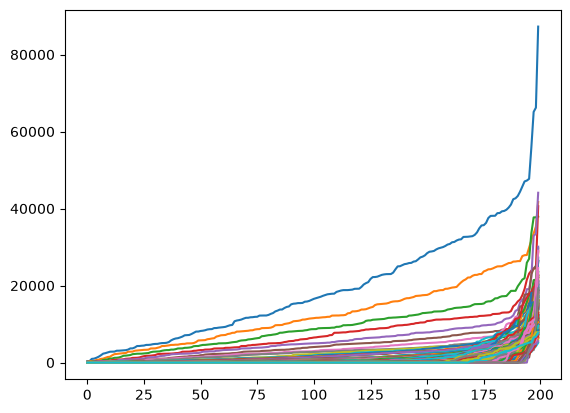

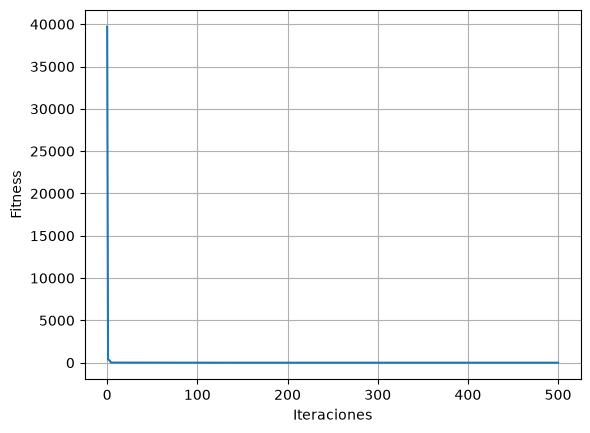

In [9]:
from tqdm import tqdm
P=[solucion(data,target_sum) for i in range(m)]

NumIter=500
dv=2
print('Mejor solucion inicial: ',min(Z))
best=solucion(data, target_sum, P[np.argmin(Z)].X)
error=[best.Z]
mejor=solucion(data, target_sum,P[np.argmin(Z)].X)
#print('Mejor solución al incio: ', best.Z)

for i in range(NumIter):
  P=prunning(P, Np)
  P=mutacion(P, Nm,50)
  P=reproduccion(P, Nc)
  Z=[xi.Z for xi in P]
  mejor=solucion(data, target_sum,P[np.argmin(Z)].X)
  if(i%dv==0):
    print('\rIteración: ',i,', Mejor valor: ',best.Z, end='')
    plt.plot(sorted([xi.Z for xi in P]))
  if(mejor.Z<best.Z):
    best=solucion(data, target_sum,mejor.X)
    print('\rIteración: ',i,', Mejor valor: ',best.Z, end='')
  error.append(best.Z)

  if(best.Z==0):
    print('\nSolución encontrada')
    break
#plt.plot(sorted(Z), label='Final')
#plt.legend()
#plt.xlabel('Población')
#plt.ylabel('Fitness')
#plt.grid()
plt.figure()
plt.plot(error)
plt.xlabel('Iteraciones')
plt.ylabel('Fitness')
plt.grid()